# BeforeIT analysys

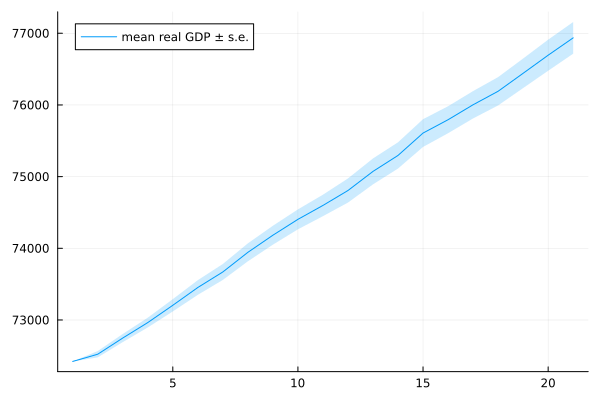

In [43]:
import BeforeIT as Bit
using Plots, Statistics, Random

parameters = Bit.AUSTRIA2010Q1.parameters
initial_conditions = Bit.AUSTRIA2010Q1.initial_conditions

T, n_sims = 20, 100
base = Bit.Model(parameters, initial_conditions)
models = Bit.ensemblerun!([deepcopy(base) for _ in 1:n_sims], T)
dv = Bit.DataVector(models)          # fields become T × n_sims matrices

g = dv.real_gdp
m, s = mean(g, dims=2), std(g, dims=2) ./ sqrt(n_sims)
plot(m, ribbon=s, fillalpha=0.2, label="mean real GDP ± s.e.")

In [44]:
using DataFrames
using CSV

function to_dataframe(dv)
    n_periods, n_sims = size(dv.collection_time)

    df = DataFrame(
        simulation = repeat(1:n_sims, inner = n_periods),
        time = vec(dv.collection_time),
    )

    for name in fieldnames(Bit.Data)
        name == :collection_time && continue

        values = getproperty(dv, name)

        # Inclui apenas séries escalares; dados setoriais são aninhados.
        eltype(values) <: Number || continue

        df[!, name] = vec(values)
    end

    return df
end

to_dataframe (generic function with 1 method)

In [45]:
df = to_dataframe(dv)

Row,simulation,time,nominal_gdp,real_gdp,nominal_gva,real_gva,nominal_household_consumption,real_household_consumption,nominal_government_consumption,real_government_consumption,nominal_capitalformation,real_capitalformation,nominal_fixed_capitalformation,real_fixed_capitalformation,nominal_fixed_capitalformation_dwellings,real_fixed_capitalformation_dwellings,nominal_exports,real_exports,nominal_imports,real_imports,operating_surplus,compensation_employees,wages,taxes_production,gdp_deflator_growth_ea,real_gdp_ea,euribor,gambling_volume
,Int64,Int64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,1,1,72422.0,72422.0,64900.9,64900.9,40512.9,40512.9,14866.9,14866.9,15944.2,15944.2,15944.2,15944.2,3173.23,3173.23,34195.6,34195.6,33097.6,33097.6,29576.1,34346.7,28335.3,978.062,0.00193832,2.35485e6,0.00164593,0.0
2,1,2,73193.3,72918.3,65595.9,65349.4,40925.5,40771.7,14886.6,14830.7,16457.5,16395.7,16113.3,16052.8,3205.54,3193.5,34553.6,34423.7,33629.9,33503.5,29892.9,34714.5,28638.8,988.536,0.00212964,2.36327e6,0.0019247,0.0
3,1,3,73015.4,72493.0,65426.5,64958.4,40892.1,40599.6,15016.4,14909.0,15934.1,15820.1,16079.1,15964.1,3202.37,3179.46,34996.6,34746.2,33824.0,33581.9,29835.3,34604.6,28548.1,986.566,-0.00100471,2.36261e6,0.00173187,0.0
4,1,4,73266.3,72549.3,65655.1,65012.6,40991.5,40590.4,15070.4,14923.0,16020.8,15864.0,16125.4,15967.6,3210.55,3179.13,35042.0,34699.1,33858.5,33527.1,29915.0,34748.5,28666.8,991.6,0.00842839,2.35264e6,0.00138188,0.0
5,1,5,73734.4,72938.1,66074.8,65361.2,41237.6,40792.3,15191.0,15027.0,16473.5,16295.6,16222.8,16047.6,3227.66,3192.8,35617.4,35232.8,34785.2,34409.5,30096.0,34980.0,28857.7,998.797,0.00849211,2.38109e6,0.00266388,0.0
6,1,6,73279.3,71863.9,65663.5,64395.2,40995.4,40203.6,15252.1,14957.5,16510.8,16191.9,16109.1,15798.0,3205.85,3143.93,35393.5,34709.9,34872.5,34199.0,29892.4,34774.0,28687.8,997.132,0.00737355,2.37495e6,0.00238239,0.0
7,1,7,74238.3,72204.7,66521.1,64698.9,41410.8,40276.4,15927.5,15491.2,16271.1,15825.4,16292.6,15846.3,3240.68,3151.9,36077.8,35089.5,35448.8,34477.8,30177.8,35326.7,29143.8,1016.57,0.00620176,2.3738e6,0.00230069,0.0
8,1,8,75556.1,72727.7,67708.2,65173.6,42122.3,40545.5,16010.1,15410.8,16936.7,16302.7,16559.5,15939.6,3284.44,3161.49,36366.5,35005.1,35879.5,34536.4,30694.4,35971.5,29675.8,1042.24,0.00451527,2.38657e6,0.00276279,0.0
9,1,9,77041.8,73750.6,69041.1,66091.7,42996.2,41159.4,16207.3,15515.0,18113.4,17339.6,16919.8,16197.0,3367.74,3223.87,35808.9,34279.2,36084.0,34542.5,31350.3,36631.1,30219.9,1059.73,0.00799396,2.35764e6,0.00154936,0.0


In [46]:
CSV.write("study-output.csv", df)

"study-output.csv"

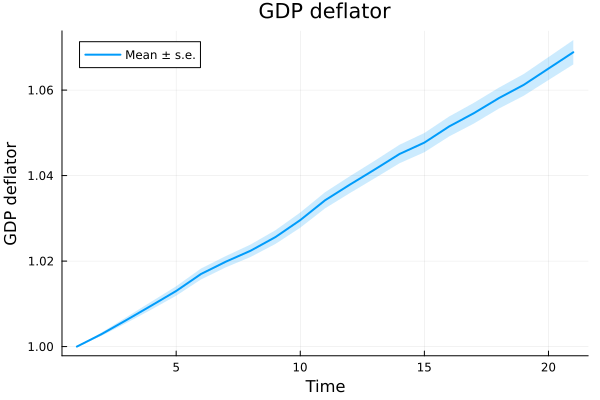

In [47]:
df.gdp_deflator = df.nominal_gdp ./ df.real_gdp

summary = combine(
    groupby(df, :time),
    :gdp_deflator => mean => :average,
    :gdp_deflator => (x -> std(x) / sqrt(length(x))) => :standard_error,
)

sort!(summary, :time)

plot(
    summary.time,
    summary.average;
    ribbon = summary.standard_error,
    label = "Mean ± s.e.",
    xlabel = "Time",
    ylabel = "GDP deflator",
    title = "GDP deflator",
    linewidth = 2,
    fillalpha = 0.2,
)

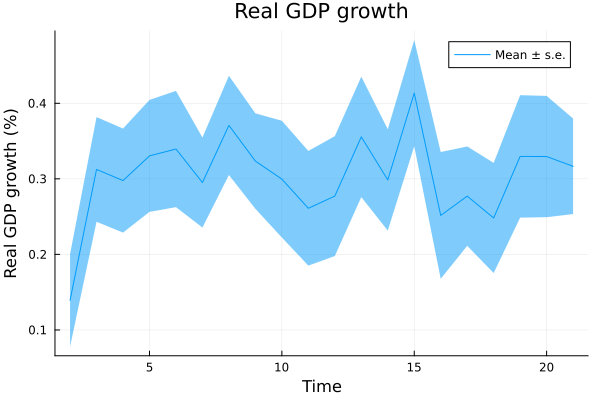

In [48]:
sort!(df, [:simulation, :time])

transform!(
    groupby(df, :simulation),
    :real_gdp => (x -> [
        missing
        100 .* (x[2:end] ./ x[1:(end - 1)] .- 1)
    ]) => :real_gdp_growth,
)

growth_summary = combine(
    groupby(dropmissing(df, :real_gdp_growth), :time),
    :real_gdp_growth => mean => :average,
    :real_gdp_growth =>
        (x -> std(x) / sqrt(length(x))) => :standard_error,
)

plot(
    growth_summary.time,
    growth_summary.average;
    ribbon = growth_summary.standard_error,
    label = "Mean ± s.e.",
    xlabel = "Time",
    ylabel = "Real GDP growth (%)",
    title = "Real GDP growth",
)

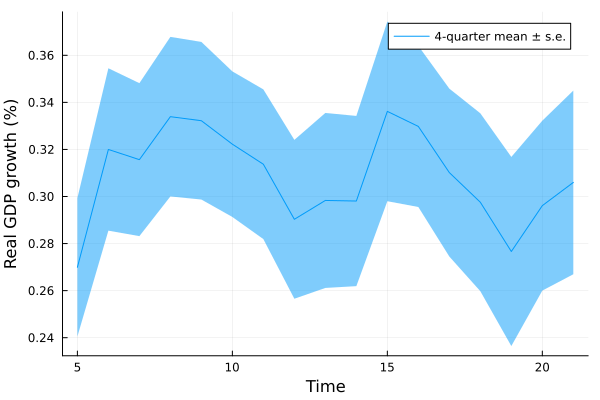

In [49]:
function filtered_growth(real_gdp, window = 4)
    growth = 100 .* (real_gdp[2:end] ./ real_gdp[1:(end - 1)] .- 1)

    vcat(
        fill(missing, window),
        [mean(@view growth[(i - window + 1):i])
        for i in window:length(growth)],
    )
end

sort!(df, [:simulation, :time])

transform!(
    groupby(df, :simulation),
    :real_gdp => filtered_growth => :filtered_growth
)

filtered_summary = combine(
    groupby(dropmissing(df, :filtered_growth), :time),
    :filtered_growth => mean => :average, 
    :filtered_growth => 
        (x -> std(x) / sqrt(length(x))) => :standard_error,
)

plot(
    filtered_summary.time,
    filtered_summary.average;
    ribbon = filtered_summary.standard_error,
    label = "4-quarter mean ± s.e.",
    xlabel = "Time",
    ylabel = "Real GDP growth (%)",
)

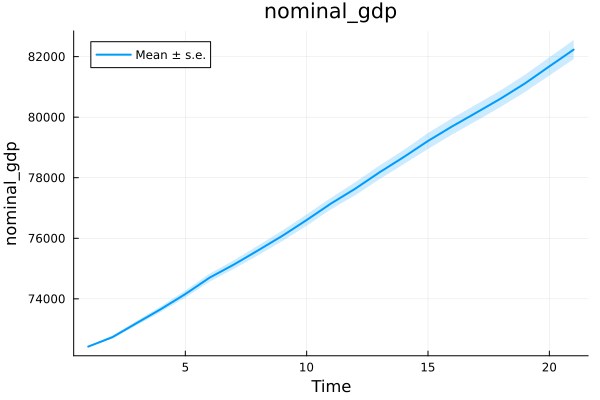

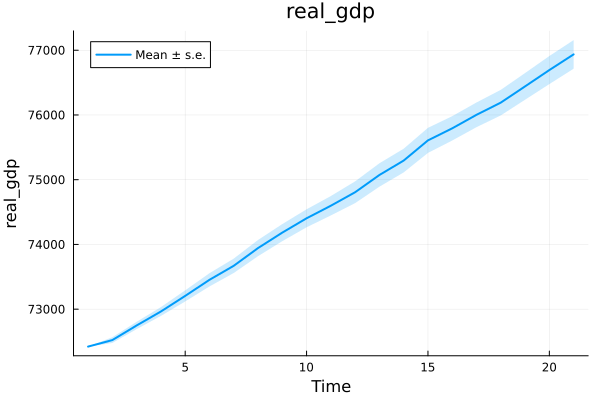

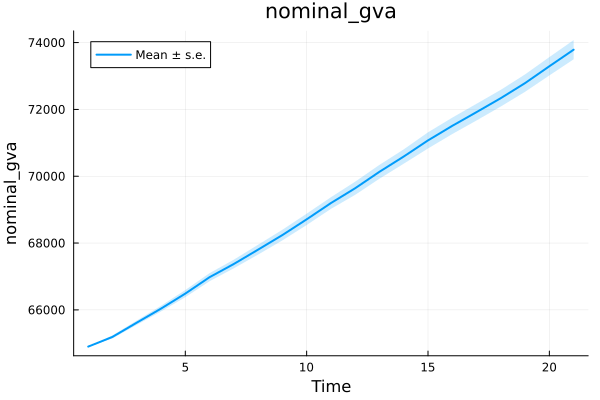

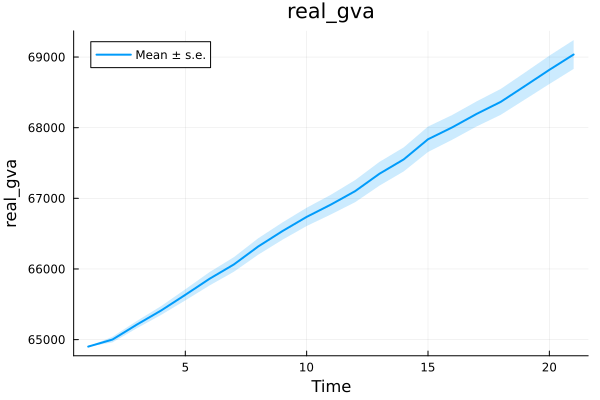

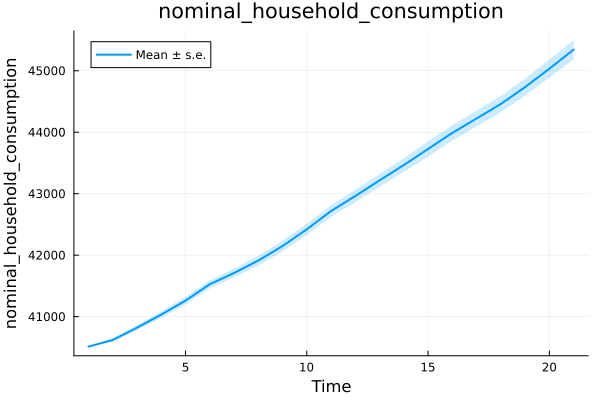

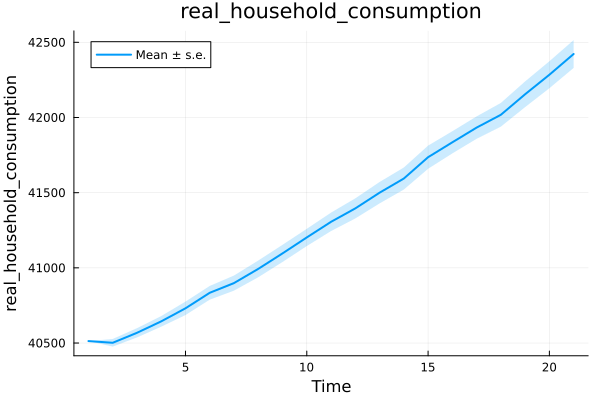

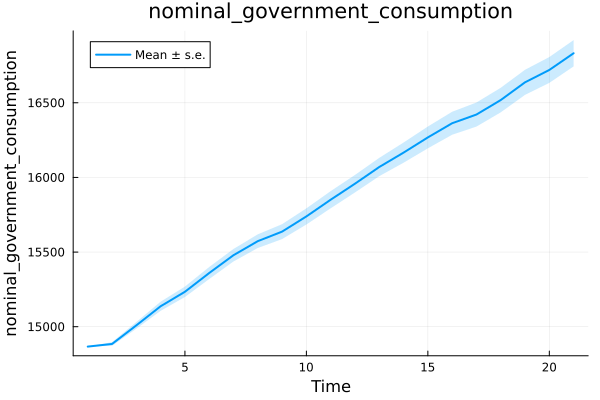

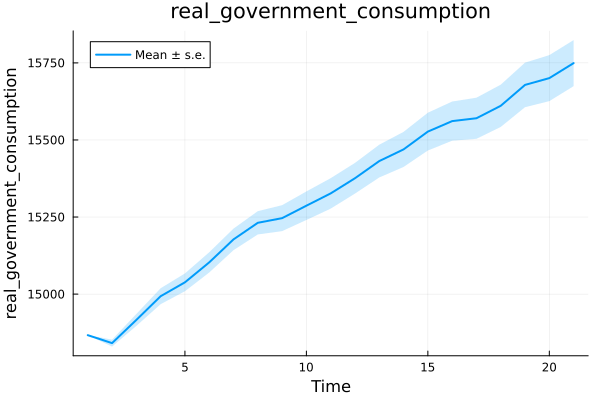

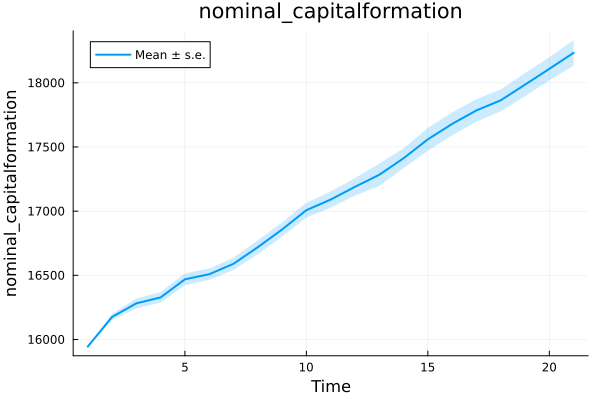

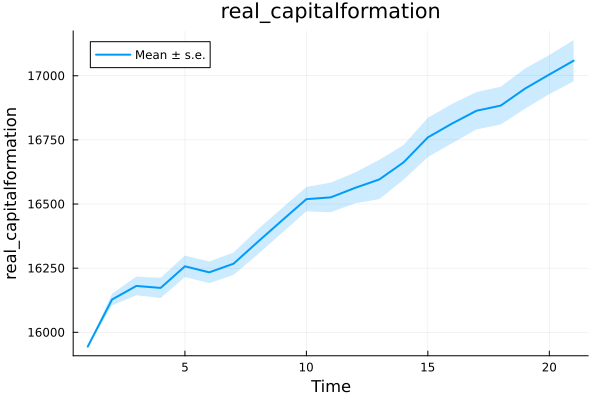

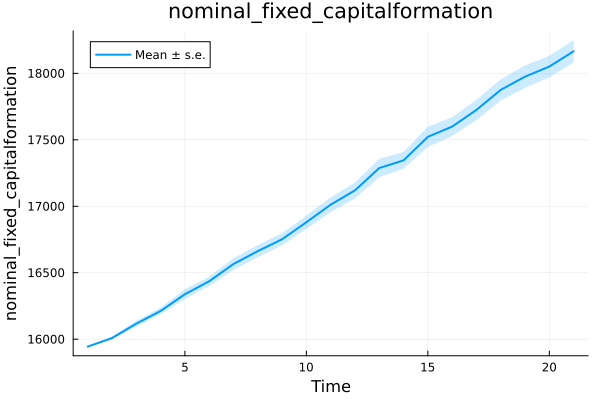

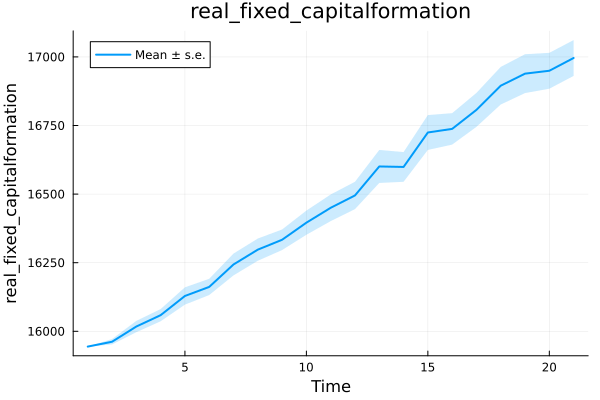

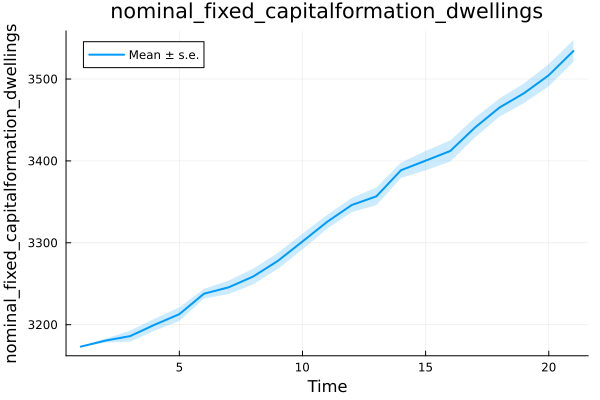

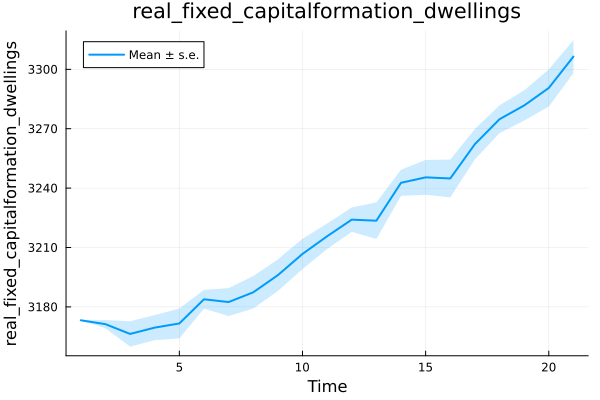

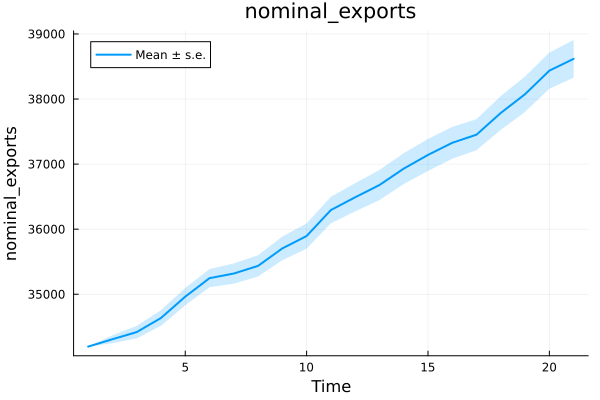

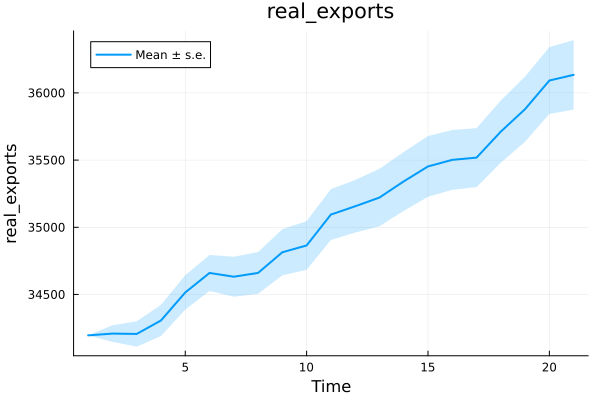

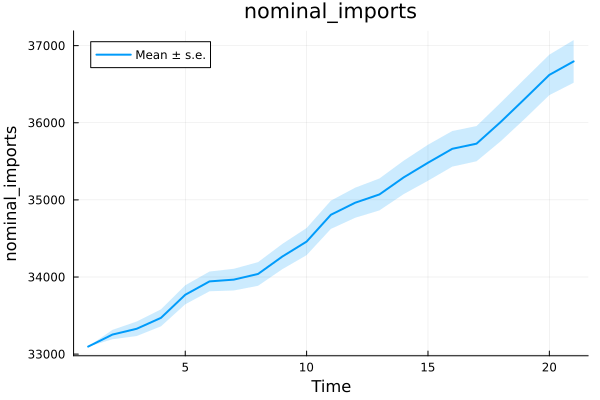

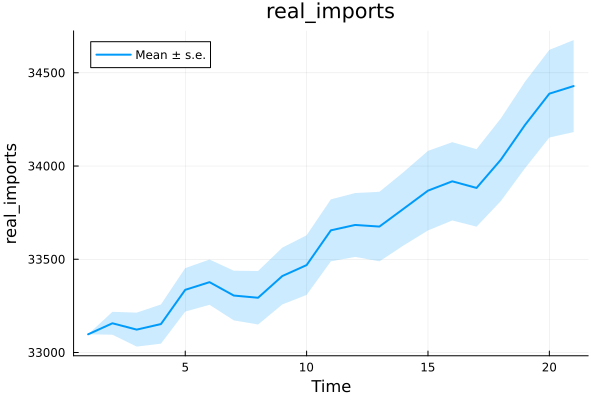

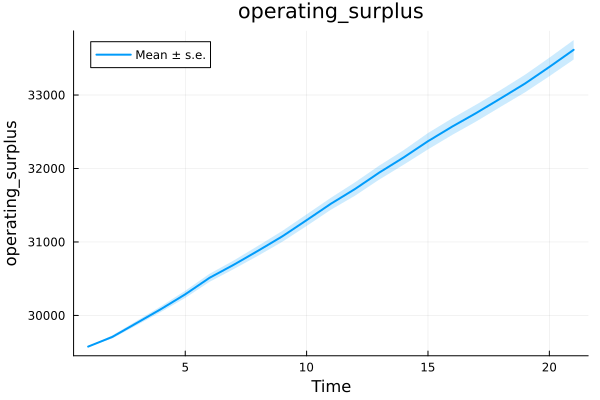

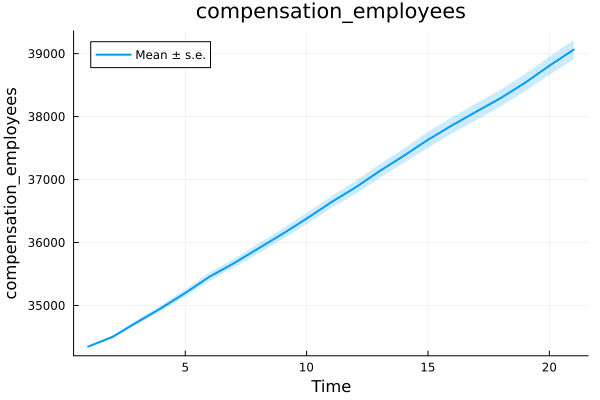

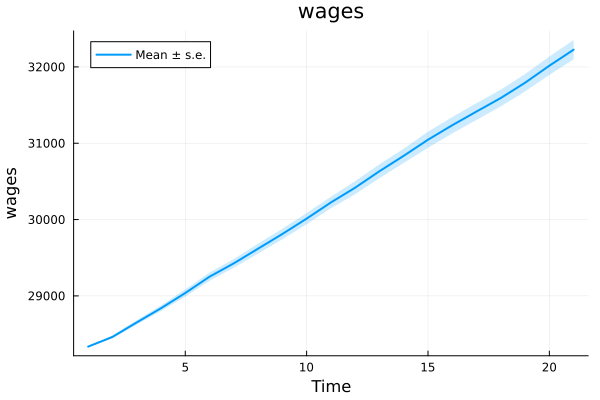

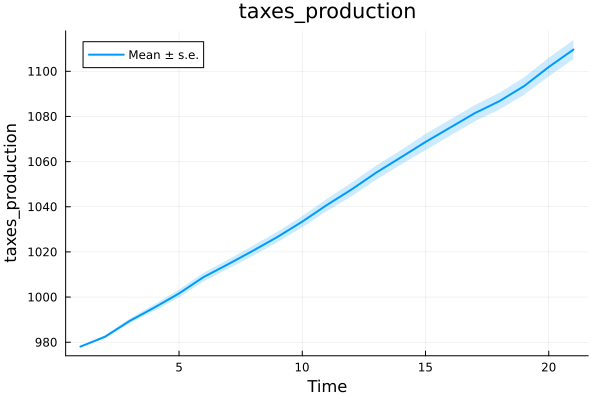

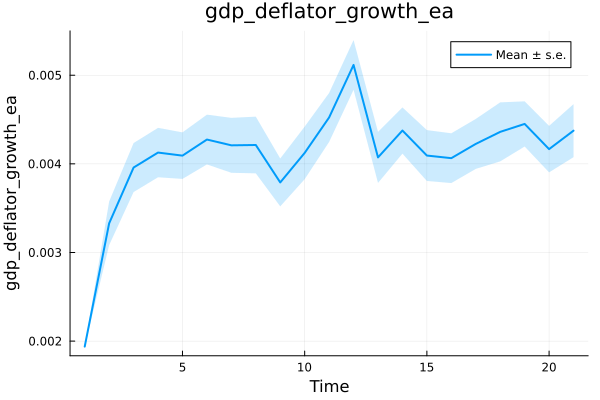

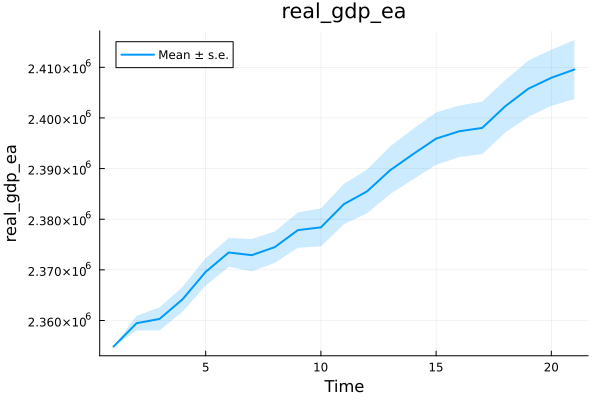

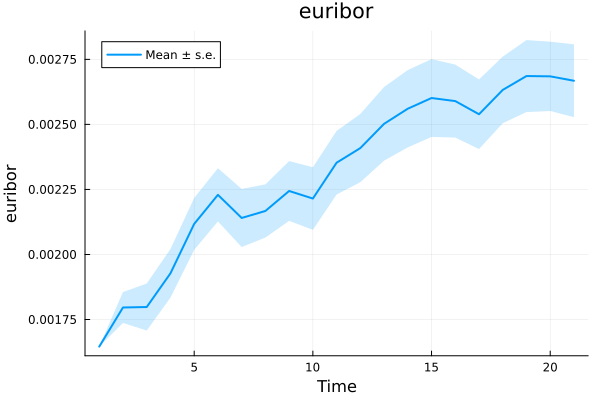

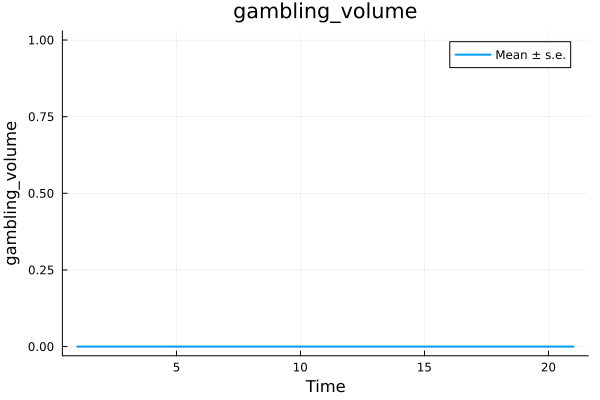

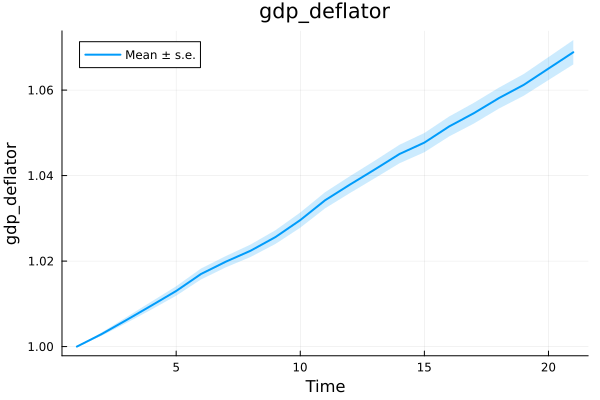

In [50]:
 n_sims = length(unique(df.simulation))

  for name in names(df)
      name in ("time", "simulation") && continue
      eltype(df[!, name]) <: Number || continue

      summary = combine(
          groupby(df, :time),
          name => mean => :average,
          name => std => :standard_deviation,
      )

      sort!(summary, :time)

      standard_error =
          summary.standard_deviation ./ sqrt(n_sims)

      p = plot(
          summary.time,
          summary.average;
          ribbon = standard_error,
          fillalpha = 0.2,
          linewidth = 2,
          label = "Mean ± s.e.",
          title = name,
          xlabel = "Time",
          ylabel = name,
      )

      display(p)

      # Optional:
      # savefig(p, "$(name).png")
  end

## Discover economic regimes (first draft)

Each simulation is represented by mean real-GDP growth, growth volatility, mean GDP-deflator inflation, and four final-state proxies available from the model: unemployment, pending insolvency, credit rationing, and household-income inequality. Cluster numbers stay unlabeled until their profiles support an economic interpretation. Because these simulations share one parameter set, the clusters describe stochastic outcomes; testing parameter-driven regimes requires a parameter sweep.

In [51]:
using Clustering

function gini_coefficient(values)
    values = sort(values)
    total = sum(values)
    iszero(total) && return 0.0
    n = length(values)
    return sum((2i - n - 1) * value for (i, value) in enumerate(values)) / (n * total)
end

@assert isapprox(gini_coefficient([0.0, 0.0, 1.0]), 2 / 3)

function final_state_features(model)
    firms = model.firms
    desired_credit = sum(firms.DL_d_i)
    incomes = [model.w_act.Y_h; model.w_inact.Y_h; firms.Y_h; model.bank.Y_h]

    return (
        final_unemployment = 100 * mean(model.w_act.O_h .== 0),
        pending_insolvency = 100 * mean((firms.D_i .< 0) .& (firms.E_i .< 0)),
        final_credit_rationing = iszero(desired_credit) ? 0.0 :
            100 * sum(max.(firms.DL_d_i .- firms.DL_i, 0)) / desired_credit,
        final_income_gini = gini_coefficient(incomes),
    )
end

regime_features = DataFrame(map(1:n_sims) do simulation
    real_gdp = dv.real_gdp[:, simulation]
    deflator = dv.nominal_gdp[:, simulation] ./ real_gdp
    growth = 100 .* diff(log.(real_gdp))
    inflation = 100 .* diff(log.(deflator))

    merge(
        (
            simulation = simulation,
            mean_growth = mean(growth),
            growth_volatility = std(growth),
            mean_inflation = mean(inflation),
        ),
        final_state_features(models[simulation]),
    )
end)

regime_features

Row,simulation,mean_growth,growth_volatility,mean_inflation,final_unemployment,pending_insolvency,final_credit_rationing,final_income_gini
,Int64,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,1,0.230581,0.842688,0.525119,3.13259,0.160256,15.0846,0.393871
2,2,0.554377,0.674673,0.273083,0.0,0.0,14.8792,0.396229
3,3,0.167577,0.673029,0.369738,4.71102,0.160256,16.0164,0.384666
4,4,0.448976,0.523523,0.541382,0.0,0.160256,16.8642,0.392845
5,5,-0.0632172,1.03727,0.452388,7.45508,0.160256,15.6246,0.396466
6,6,0.30555,0.867844,0.470499,1.77271,0.0,2.80243,0.389515
7,7,0.117718,0.540391,0.227428,5.12385,0.0,3.12565,0.389098
8,8,0.311741,0.815419,0.102449,1.52987,0.0,15.2455,0.39001
9,9,0.285123,0.643817,0.452024,2.47693,0.0,4.43117,0.387955


In [52]:
feature_names = [
    :mean_growth,
    :growth_volatility,
    :mean_inflation,
    :final_unemployment,
    :pending_insolvency,
    :final_credit_rationing,
    :final_income_gini,
]

features = Matrix{Float64}(select(regime_features, feature_names))
scales = std(features, dims = 1)
scales[iszero.(scales)] .= 1
standardized_features = (features .- mean(features, dims = 1)) ./ scales

k = 4  # ponytail: fixed first-pass k; compare silhouette scores before substantive use
clustering = kmeans(
    permutedims(standardized_features),
    k;
    init = :kmpp,
    rng = MersenneTwister(42),
)
regime_features.regime = assignments(clustering)

regime_profiles = combine(
    groupby(regime_features, :regime),
    nrow => :simulations,
    [name => mean => name for name in feature_names]...,
)
sort!(regime_profiles, :regime)

Row,regime,simulations,mean_growth,growth_volatility,mean_inflation,final_unemployment,pending_insolvency,final_credit_rationing,final_income_gini
,Int64,Int64,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,1,15,0.277281,0.836489,0.149445,2.26971,0.0,10.7609,0.400662
2,2,25,0.459029,0.706042,0.332397,0.171928,0.0,5.65579,0.3951
3,3,24,0.234193,0.630082,0.309259,3.00308,0.0,4.76209,0.395073
4,4,36,0.24368,0.706909,0.420696,2.74135,0.151353,15.7181,0.395312


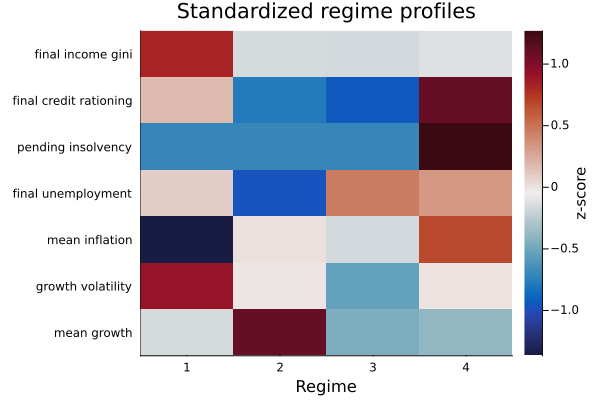

In [53]:
heatmap(
    1:k,
    1:length(feature_names),
    clustering.centers;
    xticks = 1:k,
    yticks = (1:length(feature_names), replace.(string.(feature_names), "_" => " ")),
    xlabel = "Regime",
    title = "Standardized regime profiles",
    color = :balance,
    colorbar_title = "z-score",
)

In [54]:
nb2_p_AT  = Bit.AUSTRIA2010Q1.parameters
nb2_ic_AT = Bit.AUSTRIA2010Q1.initial_conditions
nb2_p_IT  = Bit.ITALY2010Q1.parameters
nb2_ic_IT = Bit.ITALY2010Q1.initial_conditions
"Calibrations loaded: Austria and Italy ✓"

"Calibrations loaded: Austria and Italy ✓"

In [55]:
_nb03_m_p = Bit.Model(nb2_p_AT, nb2_ic_AT)
    p = _nb03_m_p.prop

    param_table = DataFrame(
        "Source"    => [
            "Census", "Census", "Census", "Census",
            "I-O tables", "I-O tables", "I-O tables",
            "Gov. statistics", "Gov. statistics", "Gov. statistics",
            "Gov. statistics", "Gov. statistics", "Gov. statistics",
            "Basel III / statute", "Basel III / statute",
            "Basel III / statute", "Basel III / statute",
            "Estimated (AR(1))", "Estimated (Taylor)", "Estimated (Taylor)",
        ],
        "Symbol"    => [
            "H_act", "H_inact", "I (firms)", "J (gov. entities)",
            "a_sg (matrix)", "ᾱ_i (mean)", "b_HH_g (mean)",
            "τ^INC", "τ^VAT", "τ^FIRM", "τ^SIF", "ψ (MPC)", "θ^DIV",
            "ζ (cap. ratio)", "ζ_LTV",
            "θ_UB (unempl. benefit)", "π* (target)",
            "ρ (smoothing)", "ξ^π (infl. weight)", "ξ^γ (growth weight)",
        ],
        "Value" => [
            p.H_act, p.H_inact, p.I, p.J,
            "$(size(p.a_sg))", round(mean(_nb03_m_p.firms.alpha_bar_i), digits=4),
            round(mean(p.b_HH_g), digits=4),
            round(p.tau_INC, digits=4), round(p.tau_VAT, digits=4),
            round(p.tau_FIRM, digits=4), round(p.tau_SIF, digits=4),
            round(p.psi, digits=4), round(p.theta_DIV, digits=4),
            round(p.zeta, digits=4), round(p.zeta_LTV, digits=4),
            round(p.theta_UB, digits=4), "0.0050",
            "see Taylor rule", "see Taylor rule", "see Taylor rule",
        ],
    )
    param_table

Row,Source,Symbol,Value
,String,String,Any
1,Census,H_act,4743
2,Census,H_inact,4130
3,Census,I (firms),624
4,Census,J (gov. entities),156
5,I-O tables,a_sg (matrix),"(62, 62)"
6,I-O tables,ᾱ_i (mean),35.3787
7,I-O tables,b_HH_g (mean),0.0161
8,Gov. statistics,τ^INC,0.2134
9,Gov. statistics,τ^VAT,0.1529


In [56]:
model_AT = Bit.Model(nb2_p_AT, nb2_ic_AT)

    # Aggregate initial conditions
    bs_table = DataFrame(
        "Sector"         => ["Households (deposits)", "Firms (deposits, sum)",
                             "Firms (debt, sum)", "Bank equity",
                             "Government debt", "Policy rate (initial)"],
        "Value (€ real)" => [
            round(sum(model_AT.w_act.D_h), sigdigits=5),
            round(sum(model_AT.firms.D_i), sigdigits=5),
            round(sum(model_AT.firms.L_i), sigdigits=5),
            round(model_AT.bank.E_k, sigdigits=5),
            round(model_AT.gov.L_G, sigdigits=5),
            round(model_AT.cb.r_bar, digits=4),
        ],
    )
    bs_table

Row,Sector,Value (€ real)
,String,Float64
1,Households (deposits),108250.0
2,"Firms (deposits, sum)",54049.0
3,"Firms (debt, sum)",236920.0
4,Bank equity,89460.0
5,Government debt,232610.0
6,Policy rate (initial),0.0016


In [58]:
Random.seed!(42)

# --- Baseline: shocks ON ---
model_shocks_on = Bit.Model(nb2_p_AT, nb2_ic_AT)
Bit.run!(model_shocks_on, 20)

# --- No-burn-in: shocks OFF (zero covariance matrix only) ---
# model.prop.C is the 3×3 covariance matrix of the three CORRELATED innovations
# (eps_Y_EA, eps_E, eps_I). The other two exogenous processes — government
# consumption and euro-area inflation — draw from their own scalar sigmas
# (gov.sigma_G, rotw.sigma_pi_EA) and are NOT silenced by zeroing C.
# That is precisely why scenario 3 below is quieter than scenario 2.
# Setting it to zero suppresses all stochastic noise; deterministic AR(1) drift remains.
Random.seed!(42)
model_no_shocks = Bit.Model(nb2_p_AT, nb2_ic_AT)
model_no_shocks.prop.C .= 0.0
Bit.run!(model_no_shocks, 20)

# --- Full steady state ---
# Bit.STEADY_STATE2010Q1 is a special calibration where all AR(1) drift and noise
# are zero, the policy rate is fixed at zero, and agent histories are pre-loaded
# with flat time series so OLS expectations stay inert every quarter.
Random.seed!(42)
nb2_ss_p, nb2_ss_ic = Bit.STEADY_STATE2010Q1.parameters, Bit.STEADY_STATE2010Q1.initial_conditions
model_steady = Bit.Model(nb2_ss_p, nb2_ss_ic)
Bit.run!(model_steady, 20)

"Simulations complete ✓"

"Simulations complete ✓"

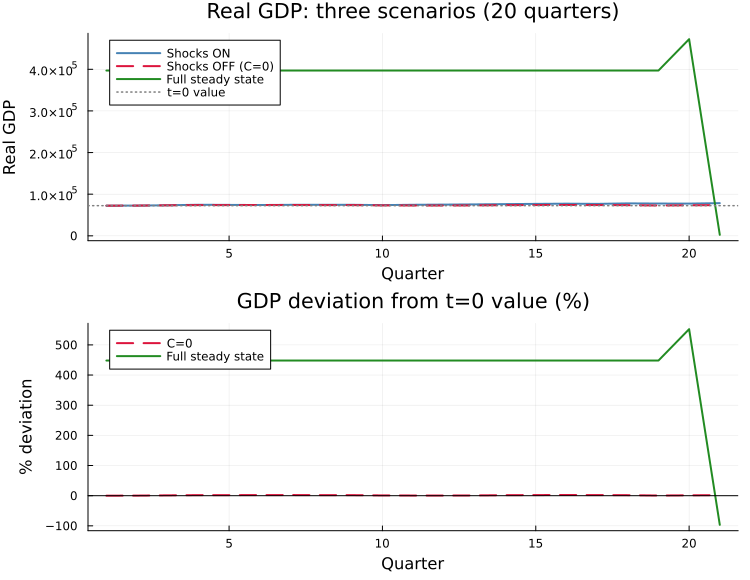

In [59]:
gdp_on     = model_shocks_on.data.real_gdp
gdp_off    = model_no_shocks.data.real_gdp
gdp_steady = model_steady.data.real_gdp
gdp_0      = gdp_on[1]

p3 = plot(
    1:21, gdp_on,
    label = "Shocks ON", lw = 2, color = :steelblue,
    title = "Real GDP: three scenarios (20 quarters)",
    xlabel = "Quarter", ylabel = "Real GDP",
)
plot!(p3, 1:21, gdp_off,
        label = "Shocks OFF (C=0)", lw = 2, color = :crimson, ls = :dash)
plot!(p3, 1:21, gdp_steady,
        label = "Full steady state", lw = 2, color = :forestgreen, ls = :solid)
hline!(p3, [gdp_0], label = "t=0 value", color = :grey, ls = :dot, lw = 1.5)

p4 = plot(
    1:21, (gdp_off .- gdp_0) ./ gdp_0 .* 100,
    label = "C=0", color = :crimson, lw = 2, ls = :dash,
    title = "GDP deviation from t=0 value (%)",
    xlabel = "Quarter", ylabel = "% deviation",
)
plot!(p4, 1:21, (gdp_steady .- gdp_0) ./ gdp_0 .* 100,
        label = "Full steady state", color = :forestgreen, lw = 2)
hline!(p4, [0], color = :black, lw = 1, label = "")

plot(p3, p4, layout = (2, 1), size = (750, 580))